In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import importlib
import features
importlib.reload(features)
from features import build_features
train = pd.read_csv("../data/train.csv", parse_dates=["cookie_created_at","window_start_ts","window_end_ts"])
test = pd.read_csv("../data/test.csv", parse_dates=["cookie_created_at","window_start_ts","window_end_ts"])
events = pd.read_csv("../data/events.csv.gz", parse_dates=["event_ts"])

Xtr = build_features(events, train)
Xte = build_features(events, test)

# 1. базовые проверки
print(Xtr.shape, Xte.shape)
assert Xtr.cookie_id.tolist() == train.cookie_id.tolist()  # порядок строк совпадает
assert set(Xtr.columns) == set(Xte.columns)                # одинаковые колонки
print("пропуски train:\n", Xtr.isna().sum()[lambda s: s > 0])
print("пропуски test:\n", Xte.isna().sum()[lambda s: s > 0])

(11091, 36) (4909, 36)
пропуски train:
 Series([], dtype: int64)
пропуски test:
 Series([], dtype: int64)


In [2]:
# 2. глазами: распределение каждого нового признака по классам
Xtr_t = Xtr.merge(train[["cookie_id","target"]], on="cookie_id")
num_cols = Xtr_t.select_dtypes("number").columns.difference(["target"])
print(Xtr_t.groupby("target")[num_cols].median().T)

target                              0            1
category_nunique             2.000000     2.000000
category_nunique_ratio       0.176471     0.090909
conversion_share             0.111111     0.062500
cookie_age_days             61.782367    18.968403
cookie_age_log1p             4.139674     2.994151
events_per_age_day           0.219745     1.407212
events_per_min               0.093511     0.146672
gap_mean                   649.790598   428.260870
gap_median                  59.500000    25.000000
gap_min                      7.000000     5.000000
gap_std                   1666.238095  1356.622870
has_events                   1.000000     1.000000
is_bot_ua                    0.000000     0.000000
is_headless                  0.000000     0.000000
is_raw_client                0.000000     0.000000
item_nunique                 6.000000    10.000000
item_nunique_ratio           0.527778     0.500000
item_revisit_ratio           1.000000     1.125000
location_nunique             5.

In [3]:
print("night_share (mean):", Xtr_t.groupby("target").night_share.mean().to_dict())
print("is_raw_client (mean):", Xtr_t.groupby("target").is_raw_client.mean().to_dict())
print("is_bot_ua (mean):", Xtr_t.groupby("target").is_bot_ua.mean().to_dict())

night_share (mean): {0: 0.10460360787169436, 1: 0.1674481547511512}
is_raw_client (mean): {0: 0.015306122448979591, 1: 0.048943270300333706}
is_bot_ua (mean): {0: 0.03600863422291994, 1: 0.13236929922135707}


In [4]:
# 3. точечная сверка с тем, что видели в EDA - должны совпасть цифры
print("cookie_age_days медиана:", Xtr_t.groupby("target").cookie_age_days.median())  # ожидаем ~19 vs ~62
print("is_headless доля:", Xtr_t.groupby("target").is_headless.mean())              # ожидаем ~0.08 vs ~0.02
print("top_bigram_share медиана:", Xtr_t.groupby("target").top_bigram_share.median())

cookie_age_days медиана: target
0    61.782367
1    18.968403
Name: cookie_age_days, dtype: float64
is_headless доля: target
0    0.020703
1    0.083426
Name: is_headless, dtype: float64
top_bigram_share медиана: target
0    0.4375
1    0.6000
Name: top_bigram_share, dtype: float64


In [5]:
import sys
sys.path.append("..")
from metric import precision_at_recall

is_valid = train.window_start_ts.ge("2026-04-17").values  # последние ~3 дня как holdout, как в quickstart

# было только platform_canon - first_event_name (тоже строковый) утекал в
# RandomForest как есть и валил fit с "could not convert string to float"
cat_cols = ["platform_canon", "first_event_name"]
feature_cols = Xtr_t.columns.difference(["cookie_id", "target"] + cat_cols)

from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc_cols = [c + "_enc" for c in cat_cols]
Xtr_t[enc_cols] = enc.fit_transform(Xtr_t[cat_cols])
feature_cols = list(feature_cols) + enc_cols

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=42, class_weight="balanced")
model.fit(Xtr_t.loc[~is_valid, feature_cols], Xtr_t.loc[~is_valid, "target"])
p_va = model.predict_proba(Xtr_t.loc[is_valid, feature_cols])[:, 1]

score = precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p_va)
print("P@R0.7 на валидации (полный набор признаков):", round(score, 4))
print("для сравнения: baseline quickstart (2 признака) был 0.1025")

P@R0.7 на валидации (полный набор признаков): 0.4402
для сравнения: baseline quickstart (2 признака) был 0.1025


In [6]:
cutoffs = ["2026-04-15", "2026-04-16", "2026-04-17", "2026-04-18"]
results = []

for cutoff in cutoffs:
    is_valid = train.window_start_ts.ge(cutoff).values
    n_bots_valid = Xtr_t.loc[is_valid, "target"].sum()

    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=42, class_weight="balanced")
    model.fit(Xtr_t.loc[~is_valid, feature_cols], Xtr_t.loc[~is_valid, "target"])
    p_va = model.predict_proba(Xtr_t.loc[is_valid, feature_cols])[:, 1]

    score = precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p_va)
    results.append((cutoff, is_valid.sum(), n_bots_valid, score))
    print(f"cutoff={cutoff}: holdout={is_valid.sum()} куки, ботов={n_bots_valid}, P@R0.7={score:.4f}")

import numpy as np
scores = [r[3] for r in results]
print(f"\nсреднее={np.mean(scores):.4f}, std={np.std(scores):.4f}")

cutoff=2026-04-15: holdout=3492 куки, ботов=285, P@R0.7=0.4642
cutoff=2026-04-16: holdout=2691 куки, ботов=220, P@R0.7=0.4201
cutoff=2026-04-17: holdout=1951 куки, ботов=160, P@R0.7=0.4402
cutoff=2026-04-18: holdout=1238 куки, ботов=94, P@R0.7=0.4891

среднее=0.4534, std=0.0259


## Корреляция признаков с таргетом

Отдельно от feature_importances_ (которые смотрят на конкретную модель и её сплиты) считаем прямую корреляцию каждого признака с target - это не зависит от модели и помогает понять, какие признаки несут поведенческий сигнал, а не просто дублируют объём активности (n_events и то, что от него линейно зависит).

In [7]:
num_cols = Xtr_t.select_dtypes(include=["number"]).columns.difference(["target"])

pearson = Xtr_t[num_cols].corrwith(Xtr_t["target"]).rename("pearson")
spearman = Xtr_t[num_cols].corrwith(Xtr_t["target"], method="spearman").rename("spearman")

corr_table = pd.concat([pearson, spearman], axis=1)
corr_table["abs_pearson"] = corr_table["pearson"].abs()
corr_table = corr_table.sort_values("abs_pearson", ascending=False).drop(columns="abs_pearson")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(corr_table)

# platform_canon - категориальный, смотрим через one-hot
plat_dummies = pd.get_dummies(Xtr_t["platform_canon"], prefix="platform")
plat_corr = plat_dummies.corrwith(Xtr_t["target"]).rename("pearson")
print("\nplatform_canon (one-hot vs target):")
print(plat_corr)

                          pearson  spearman
search_page_mean           0.2633    0.1990
n_item_views               0.2527    0.1758
events_per_age_day         0.2370    0.1921
n_searches                 0.2351    0.1555
location_nunique           0.2183    0.2003
n_events                   0.1944    0.1564
same_query_as_prev_share   0.1647    0.1731
pointer_missing_share      0.1618    0.1409
cookie_age_log1p          -0.1597   -0.1281
category_nunique_ratio    -0.1503   -0.2091
top_bigram_share           0.1432    0.1562
item_nunique               0.1429    0.1566
query_diversity           -0.1305   -0.1573
is_bot_ua                  0.1285    0.1285
category_nunique          -0.1091   -0.1046
is_headless                0.1080    0.1080
cookie_age_days           -0.1026   -0.1281
gap_mean                  -0.0839   -0.0846
item_revisit_ratio         0.0741    0.0973
is_raw_client              0.0690    0.0690
platform_canon_enc         0.0670    0.0677
conversion_share          -0.065

c:\Users\katyazavr\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\katyazavr\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\katyazavr\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


**Вывод из таблицы**:

- Топ-5 по модулю (`search_page_mean`, `n_item_views`, `n_searches`, `location_nunique`, `n_events`) - почти все объёмные и сильно скоррелированы между собой: это, по сути, одна и та же информация "сколько действий", а не пять независимых сигналов.
- `category_nunique_ratio` и `query_diversity` - единственные по-настоящему поведенческие сигналы в топе, не сводящиеся к объёму. Им стоит уделять больше внимания при добавлении новых признаков.
- `item_nunique_ratio` (-0.012) и `location_nunique_ratio` (-0.001) - практически ноль. Это и есть причина, почему их не включаем в финальный список ниже: несмотря на то что они были придуманы как честная версия сырых count-признаков (контроль на n_events), сами по себе линейного/монотонного сигнала почти не несут.
- `item_revisit_ratio` (0.074) и `conversion_share` (-0.065) - слабые. Проверяем ablation'ом ниже, стоит ли их оставлять.

## Финальный список признаков (cols_final)

Список фиксируем явно (не через `columns.difference(...)`), чтобы не тащить случайные колонки.

- `item_nunique_ratio`/`location_nunique_ratio` почти не коррелируют с target по отдельности (≈0), но входят в baseline, который уже подтверждён и на CV (0.5300/0.0172), и на LB (0.53566) - оставляем, корреляция ≈0 не значит бесполезность для дерева (может работать через взаимодействия).
- `item_revisit_ratio`/`conversion_share` по ablation ниже дают шумный, невоспроизводимый эффект (std скачет в 2-4 раза между вариантами) - убираем.
- Добавлены: `cookie_age_log1p` (сглаживает длинный хвост возраста - разница между 0.1 и 1 днём важнее для модели, чем между 100 и 101), `events_per_age_day` (интенсивность активности относительно возраста куки), `first_event_name` (категориальный - какое действие первое в окне).

In [8]:
cols_final = [
    "n_events", "n_event_types", "span_sec", "night_share",
    "gap_mean", "gap_median", "gap_std", "gap_min", "n_sessions", "events_per_min",
    "top_bigram_share",
    "item_nunique", "category_nunique", "location_nunique", "seller_pro_share",
    "item_nunique_ratio", "category_nunique_ratio", "location_nunique_ratio",
    "n_searches", "query_diversity", "same_query_as_prev_share", "search_page_mean",
    "pointer_missing_share",
    "is_headless", "is_raw_client", "is_bot_ua",
    "cookie_age_days", "cookie_age_log1p", "events_per_age_day",
    "platform_canon", "first_event_name",
]
cat_features_final = ["platform_canon", "first_event_name"]
print(len(cols_final), "признаков:")
print(cols_final)

31 признаков:
['n_events', 'n_event_types', 'span_sec', 'night_share', 'gap_mean', 'gap_median', 'gap_std', 'gap_min', 'n_sessions', 'events_per_min', 'top_bigram_share', 'item_nunique', 'category_nunique', 'location_nunique', 'seller_pro_share', 'item_nunique_ratio', 'category_nunique_ratio', 'location_nunique_ratio', 'n_searches', 'query_diversity', 'same_query_as_prev_share', 'search_page_mean', 'pointer_missing_share', 'is_headless', 'is_raw_client', 'is_bot_ua', 'cookie_age_days', 'cookie_age_log1p', 'events_per_age_day', 'platform_canon', 'first_event_name']


In [9]:
import lightgbm as lgb

Xtr_t["platform_canon"] = Xtr_t["platform_canon"].astype("category")
Xtr_t["first_event_name"] = Xtr_t["first_event_name"].astype("category")

def eval_lgb(cutoff):
    is_valid = train.window_start_ts.ge(cutoff).values
    model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=15,
        min_child_samples=20, random_state=42,
        class_weight="balanced", verbosity=-1,
    )
    model.fit(
        Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"],
        categorical_feature=cat_features_final,
    )
    p_va = model.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
    return precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p_va)

for cutoff in cutoffs:
    print(cutoff, round(eval_lgb(cutoff), 4))

2026-04-15 0.4662
2026-04-16 0.4363
2026-04-17 0.4516
2026-04-18 0.5238


In [10]:
is_valid = train.window_start_ts.ge("2026-04-16").values  # средний по размеру и стабильности срез

model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=15,
    min_child_samples=20, random_state=42,
    class_weight="balanced", verbosity=-1,
)
model.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"], categorical_feature=cat_features_final)

importances = pd.Series(model.feature_importances_, index=cols_final).sort_values(ascending=False)
print(importances)

gap_median                  810
gap_min                     480
item_nunique_ratio          458
cookie_age_days             413
search_page_mean            379
events_per_age_day          364
seller_pro_share            351
top_bigram_share            337
category_nunique_ratio      337
location_nunique_ratio      330
span_sec                    322
gap_std                     316
location_nunique            261
gap_mean                    237
query_diversity             210
n_searches                  181
category_nunique            179
pointer_missing_share       146
n_events                    142
n_event_types               118
events_per_min              118
item_nunique                103
same_query_as_prev_share    101
platform_canon               91
night_share                  70
first_event_name             49
n_sessions                   46
is_headless                  30
is_bot_ua                    14
is_raw_client                 7
cookie_age_log1p              0
dtype: i

In [11]:
model_gain = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=15,
    min_child_samples=20, random_state=42,
    class_weight="balanced", verbosity=-1, importance_type="gain",
)
model_gain.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"], categorical_feature=cat_features_final)
print(pd.Series(model_gain.feature_importances_, index=cols_final).sort_values(ascending=False))

gap_median                 25836.7770
gap_min                     8898.8126
category_nunique_ratio      8524.8064
item_nunique_ratio          6538.8286
search_page_mean            6186.2553
category_nunique            5902.2237
cookie_age_days             4996.8601
location_nunique            4655.4733
location_nunique_ratio      4064.2337
top_bigram_share            3693.4612
n_events                    3055.1995
seller_pro_share            2766.5756
query_diversity             2621.4179
events_per_age_day          2558.9626
gap_std                     2431.2810
span_sec                    2198.4398
gap_mean                    1935.3777
item_nunique                1841.5501
n_searches                  1491.7614
pointer_missing_share       1482.8625
n_event_types               1075.8128
events_per_min               918.2804
same_query_as_prev_share     676.9824
platform_canon               625.5813
night_share                  509.1476
first_event_name             440.6191
n_sessions  

In [12]:
from catboost import CatBoostClassifier

def eval_catboost(cutoff):
    is_valid = train.window_start_ts.ge(cutoff).values
    model = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        cat_features=["platform_canon", "first_event_name"], auto_class_weights="Balanced",
        random_state=42, verbose=False,
    )
    model.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
    p_va = model.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
    return precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p_va)

scores_cb = [eval_catboost(c) for c in cutoffs]
print(list(zip(cutoffs, scores_cb)))
print("среднее:", np.mean(scores_cb), "std:", np.std(scores_cb))

[('2026-04-15', 0.49385749385749383), ('2026-04-16', 0.43175487465181056), ('2026-04-17', 0.5114155251141552), ('2026-04-18', 0.5454545454545454)]
среднее: 0.4956206097695013 std: 0.04127602571847278


In [13]:
for col in ["item_nunique", "category_nunique", "location_nunique"]:
    Xtr_t[f"{col}_ratio"] = Xtr_t[col] / Xtr_t["n_events"].clip(lower=1)

print(Xtr_t.groupby("target")[[c+"_ratio" for c in ["item_nunique","category_nunique","location_nunique"]]].median())

# и проверка внутри бинов n_events, как делали для n_platforms
bins = pd.cut(Xtr_t.n_events, [0,5,10,20,40,1000])
print(Xtr_t.groupby([bins, "target"]).item_nunique.mean())

        item_nunique_ratio  category_nunique_ratio  location_nunique_ratio
target                                                                    
0                   0.5278                  0.1765                  0.4159
1                   0.5000                  0.0909                  0.4074
n_events    target
(0, 5]      0         1.8568
            1         2.4691
(5, 10]     0         4.1498
            1         4.8201
(10, 20]    0         7.7262
            1         8.3306
(20, 40]    0        15.0516
            1        14.7478
(40, 1000]  0        31.8135
            1        29.8488
Name: item_nunique, dtype: float64


In [14]:
def eval_ensemble(cutoff):
    is_valid = train.window_start_ts.ge(cutoff).values

    m_lgb = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=15,
        min_child_samples=20, random_state=42,
        class_weight="balanced", verbosity=-1,
    )
    m_lgb.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"],
              categorical_feature=cat_features_final)
    p_lgb = m_lgb.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]

    m_cb = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        cat_features=cat_features_final, auto_class_weights="Balanced",
        random_state=42, verbose=False,
    )
    m_cb.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
    p_cb = m_cb.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]

    from scipy.stats import rankdata
    p_ens = rankdata(p_lgb) + rankdata(p_cb)

    y_true = Xtr_t.loc[is_valid, "target"].values
    return {
        "lgb": precision_at_recall(y_true, p_lgb),
        "cb": precision_at_recall(y_true, p_cb),
        "ensemble": precision_at_recall(y_true, p_ens),
    }

results = [eval_ensemble(c) for c in cutoffs]
for c, r in zip(cutoffs, results):
    print(c, r)

print(pd.DataFrame(results).mean())

2026-04-15 {'lgb': 0.4662004662004662, 'cb': 0.49385749385749383, 'ensemble': 0.4914004914004914}
2026-04-16 {'lgb': 0.43626062322946174, 'cb': 0.43175487465181056, 'ensemble': 0.44126074498567336}
2026-04-17 {'lgb': 0.45161290322580644, 'cb': 0.5114155251141552, 'ensemble': 0.5209302325581395}
2026-04-18 {'lgb': 0.5238095238095238, 'cb': 0.5454545454545454, 'ensemble': 0.532258064516129}
lgb        0.4695
cb         0.4956
ensemble   0.4965
dtype: float64


In [15]:
import optuna

tuning_cutoffs = ["2026-04-15", "2026-04-16"]      # только эти видит Optuna
holdout_cutoff = "2026-04-18"                        # его Optuna вообще не видит

def objective(trial):
    params = dict(
        iterations=trial.suggest_int("iterations", 200, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        auto_class_weights=trial.suggest_categorical("auto_class_weights", ["Balanced", None]),
        cat_features=["platform_canon", "first_event_name"], random_state=42, verbose=False,
    )
    scores = []
    for cutoff in tuning_cutoffs:
        is_valid = train.window_start_ts.ge(cutoff).values
        m = CatBoostClassifier(**params)
        m.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
        p = m.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
        scores.append(precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p))
    return np.mean(scores)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)
print("подбор (на tuning_cutoffs):", study.best_value, study.best_params)

is_valid = train.window_start_ts.ge(holdout_cutoff).values
m_final = CatBoostClassifier(**study.best_params, cat_features=["platform_canon", "first_event_name"], random_state=42, verbose=False)
m_final.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
p = m_final.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
print("честная проверка на holdout_cutoff:", precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p))

[I 2026-09-28 21:06:11,042] A new study created in memory with name: no-name-2f494ac0-6f8c-4487-8a30-301269b1cc25


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-28 21:06:59,256] Trial 0 finished with value: 0.45374569079819677 and parameters: {'iterations': 425, 'learning_rate': 0.13125830316209655, 'depth': 7, 'l2_leaf_reg': 3.968793330444372, 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.45374569079819677.
[I 2026-09-28 21:07:23,732] Trial 1 finished with value: 0.4373060211049038 and parameters: {'iterations': 234, 'learning_rate': 0.10440040750544663, 'depth': 7, 'l2_leaf_reg': 5.105903209394756, 'auto_class_weights': None}. Best is trial 0 with value: 0.45374569079819677.
[I 2026-09-28 21:08:33,684] Trial 2 finished with value: 0.4829126917039005 and parameters: {'iterations': 700, 'learning_rate': 0.01777174904859463, 'depth': 4, 'l2_leaf_reg': 1.5254729458052607, 'auto_class_weights': None}. Best is trial 2 with value: 0.4829126917039005.
[I 2026-09-28 21:09:49,846] Trial 3 finished with value: 0.4951774629953844 and parameters: {'iterations': 459, 'learning_rate': 0.022004527434741072, 'depth': 7, 'l2_leaf

In [21]:
best_params = study.best_params

scores_tuned = []
for cutoff in cutoffs:
    is_valid = train.window_start_ts.ge(cutoff).values
    m = CatBoostClassifier(**best_params, cat_features=["platform_canon", "first_event_name"], random_state=42, verbose=False)
    m.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
    p = m.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
    score = precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p)
    scores_tuned.append(score)
    print(cutoff, round(score, 4))

print("среднее:", np.mean(scores_tuned), "std:", np.std(scores_tuned))

2026-04-15 0.5391
2026-04-16 0.5133
2026-04-17 0.5283
2026-04-18 0.5593
среднее: 0.5350102029938933 std: 0.01675220528075812


In [25]:
from scipy.stats import rankdata

seeds = [42, 1, 7, 123, 2026]

def eval_multiseed(cutoff, seeds=seeds):
    is_valid = train.window_start_ts.ge(cutoff).values
    y_true = Xtr_t.loc[is_valid, "target"].values
    ranks = np.zeros(is_valid.sum())
    singles = []
    for seed in seeds:
        m = CatBoostClassifier(**best_params, cat_features=cat_features_final, random_state=seed, verbose=False)
        m.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
        p = m.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
        singles.append(precision_at_recall(y_true, p))
        ranks += rankdata(p)
    return singles, precision_at_recall(y_true, ranks)

single_all, ens_all = [], []
for cutoff in cutoffs:
    singles, ens = eval_multiseed(cutoff)
    single_all.append(singles)
    ens_all.append(ens)
    print(cutoff, "seeds:", [round(s, 4) for s in singles], "| rank-avg:", round(ens, 4))

single_all = np.array(single_all)
print("\nодин seed=42 (как в scores_tuned): mean=", single_all[:, 0].mean(), "std=", single_all[:, 0].std())
print("multi-seed rank-average:  mean=", np.mean(ens_all), "std=", np.std(ens_all))

2026-04-15 seeds: [0.5391, 0.4988, 0.5333, 0.5249, 0.5263] | rank-avg: 0.5432
2026-04-16 seeds: [0.5133, 0.4984, 0.5016, 0.4843, 0.5032] | rank-avg: 0.5133
2026-04-17 seeds: [0.5283, 0.5045, 0.4978, 0.5022, 0.5114] | rank-avg: 0.5045
2026-04-18 seeds: [0.5593, 0.5234, 0.5197, 0.541, 0.5726] | rank-avg: 0.5641

один seed=42 (как в scores_tuned): mean= 0.5350102029938933 std= 0.01675220528075812
multi-seed rank-average:  mean= 0.5312959112959112 std= 0.023766830320639788


In [34]:
final_model = CatBoostClassifier(
    **best_params, cat_features=["platform_canon", "first_event_name"], random_state=42, verbose=False,
)
final_model.fit(Xtr_t[cols_final], Xtr_t["target"])

p_test = final_model.predict_proba(Xte[cols_final])[:, 1]

sub2 = pd.DataFrame({"cookie_id": Xte.cookie_id, "score": p_test})

assert set(sub2.cookie_id) == set(test.cookie_id) and sub2.cookie_id.is_unique
assert sub2.score.between(0, 1).all() and sub2.score.notna().all()
assert list(sub2.columns) == ["cookie_id", "score"]

sub2.to_csv("submission.csv", index=False)
print(sub2.shape)
sub2.head()

(4909, 2)


,cookie_id,score
0,ck_315fb710a0e371e7,0.0062
1,ck_a76ee3b3e3e522fd,0.0811
2,ck_94c9a4d382689e82,0.0413
3,ck_8eaf9509ad9462a0,0.0118
4,ck_9a88a5a989cb5bc6,0.0064


In [27]:
is_valid = train.window_start_ts.ge("2026-04-17").values
m = CatBoostClassifier(**best_params, cat_features=["platform_canon", "first_event_name"], random_state=42, verbose=False)
m.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
p_va = m.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]

from metric import pr_curve
prec, rec = pr_curve(Xtr_t.loc[is_valid, "target"].values, p_va)
ok = rec >= 0.70
threshold_idx = prec[ok].argmax()

valid_df = Xtr_t.loc[is_valid].copy()
valid_df["score"] = p_va
valid_df = valid_df.sort_values("score", ascending=False)
valid_df["cum_tp"] = valid_df.target.cumsum()
valid_df["cum_n"] = range(1, len(valid_df)+1)
valid_df["recall"] = valid_df.cum_tp / valid_df.target.sum()
valid_df["precision"] = valid_df.cum_tp / valid_df.cum_n

best_row = valid_df[valid_df.recall >= 0.70].precision.idxmax()
threshold = valid_df.loc[best_row, "score"]
print("порог:", threshold, "| precision в этой точке:", valid_df.loc[best_row, "precision"])

fp = valid_df[(valid_df.score >= threshold) & (valid_df.target == 0)]
fn = valid_df[(valid_df.score < threshold) & (valid_df.target == 1)]
print(f"\nFP (люди, отмеченные как боты): {len(fp)}")
print(f"FN (боты, пропущенные): {len(fn)}")

print("\nFP - топ по score:")
print(fp.sort_values("score", ascending=False)[["cookie_id","n_events","cookie_age_days","first_event_name","is_headless","query_diversity","top_bigram_share"]].head(15))

print("\nFN - топ по score (ближе всего к порогу):")
print(fn.sort_values("score", ascending=False)[["cookie_id","n_events","cookie_age_days","first_event_name","is_headless","query_diversity","top_bigram_share"]].head(15))

порог: 0.1365588240249054 | precision в этой точке: 0.5283018867924528

FP (люди, отмеченные как боты): 100
FN (боты, пропущенные): 48

FP - топ по score:
                 cookie_id  n_events  cookie_age_days     first_event_name  \
10149  ck_e9ed95edb6b7bbf0        19           0.4270            item_view   
10235  ck_287187374bd47bfc        18           0.2308  search_results_view   
10333  ck_92819ececca6e11b        17          87.9596            item_view   
9197   ck_7713cde5002edefa        42           0.2319            item_view   
10383  ck_daa022b230eb5533        29           1.4692   contact_phone_show   
10595  ck_1f14da2bd96b78b2        29           0.3828  search_results_view   
9389   ck_77e47bc3e44cad05        12          55.2219            item_view   
11064  ck_4a68a718ff52606b        41          47.3448  search_results_view   
10709  ck_fcd3e15fb5e0f9dc        30           0.3436            item_view   
10577  ck_2bb512b98c5c8599        24           2.4380            

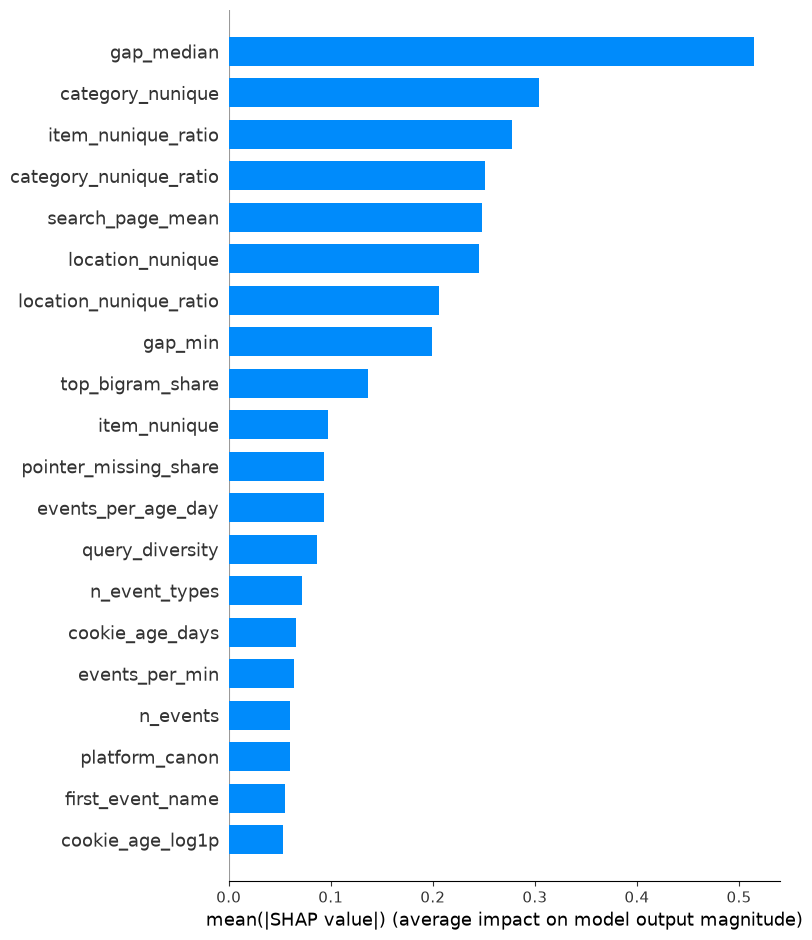

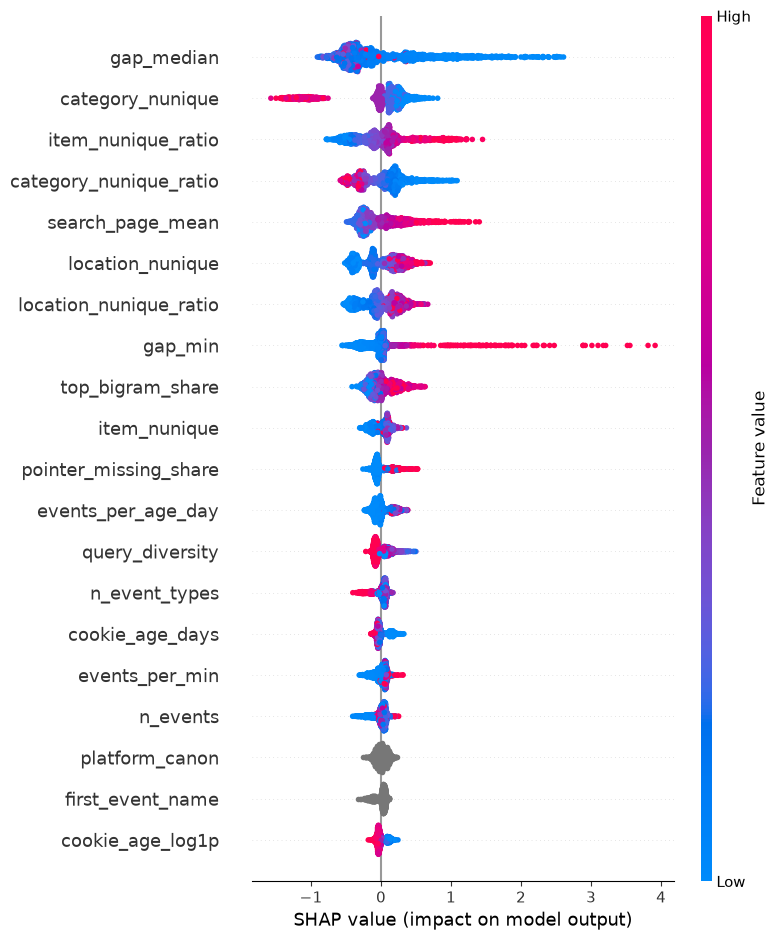

In [29]:
# SHAP на validation-фолде (та же модель m и is_valid, что и в FP/FN-анализе выше)
import shap
import matplotlib.pyplot as plt

X_va = Xtr_t.loc[is_valid, cols_final]

explainer = shap.TreeExplainer(m)
shap_values = explainer.shap_values(X_va)

shap.summary_plot(shap_values, X_va, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_validation_summary.png", dpi=120)
plt.show()

shap.summary_plot(shap_values, X_va)

In [30]:
print(events.event_name.unique())

<ArrowStringArray>
[           'item_view',  'search_results_view',        'captcha_shown',
          'photo_swipe',     'seller_page_view',         'favorite_add',
    'contact_chat_open',   'contact_phone_show',                'login',
 'contact_message_sent']
Length: 10, dtype: str


## Ablation слабых по корреляции признаков

Проверяем на СТАРЫХ `best_params` (без повторного Optuna), чтобы честно сравнить именно вклад признаков, а не смешивать его с перетюненными гиперпараметрами.

In [31]:
def eval_catboost_cols(cutoff, cols):
    is_valid = train.window_start_ts.ge(cutoff).values
    cats = [c for c in cat_features_final if c in cols]
    m = CatBoostClassifier(**best_params, cat_features=cats, random_state=42, verbose=False)
    m.fit(Xtr_t.loc[~is_valid, cols], Xtr_t.loc[~is_valid, "target"])
    p = m.predict_proba(Xtr_t.loc[is_valid, cols])[:, 1]
    return precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p)

variants = {
    "cols_final (подтверждённый + новые дешёвые фичи)": cols_final,
    "без UA-флагов (is_headless/is_raw_client/is_bot_ua)": [c for c in cols_final if c not in ("is_headless", "is_raw_client", "is_bot_ua")],
    "без новых дешёвых фич (контроль, только подтверждённый baseline)": [c for c in cols_final if c not in ("cookie_age_log1p", "events_per_age_day", "first_event_name")],
}

for name, cols in variants.items():
    scores = [eval_catboost_cols(c, cols) for c in cutoffs]
    print(f"{name}: mean={np.mean(scores):.4f} std={np.std(scores):.4f}")

cols_final (подтверждённый + новые дешёвые фичи): mean=0.5350 std=0.0168
без UA-флагов (is_headless/is_raw_client/is_bot_ua): mean=0.5127 std=0.0168
без новых дешёвых фич (контроль, только подтверждённый baseline): mean=0.5180 std=0.0264


## Adversarial validation на полном финальном наборе признаков

Раньше проверяли train/test на дрейф только по 5 объёмным признакам. Проверяем ту же идею на всём cols_final: если модель легко отличает train от test - распределения разъехались и валидации доверять нельзя.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OrdinalEncoder

Xte["platform_canon"] = Xte["platform_canon"].astype(str)
Xte["first_event_name"] = Xte["first_event_name"].astype(str)

adv = pd.concat([
    Xtr[cols_final].assign(is_test=0),
    Xte[cols_final].assign(is_test=1),
], ignore_index=True)

cat_cols = ["platform_canon", "first_event_name"]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
adv[cat_cols] = enc.fit_transform(adv[cat_cols].astype(str))

X_adv = adv[cols_final]
y_adv = adv["is_test"]

adv_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
auc_scores = cross_val_score(adv_model, X_adv, y_adv, cv=5, scoring="roc_auc")
print("adversarial AUC (train vs test, полный cols_final):", auc_scores.mean(), "+-", auc_scores.std())
print("~0.5 - дрейфа нет, >0.6-0.7 - есть подозрительные признаки")

adv_model.fit(X_adv, y_adv)
print("\nfeature importance (что лучше всего отличает train от test):")
print(pd.Series(adv_model.feature_importances_, index=cols_final).sort_values(ascending=False).head(10))

adversarial AUC (train vs test, полный cols_final): 0.49899836692512645 +- 0.0075802900933908375
~0.5 - дрейфа нет, >0.6-0.7 - есть подозрительные признаки

feature importance (что лучше всего отличает train от test):
events_per_age_day       0.0595
cookie_age_days          0.0577
cookie_age_log1p         0.0572
gap_median               0.0557
gap_std                  0.0545
span_sec                 0.0544
events_per_min           0.0539
gap_mean                 0.0533
location_nunique_ratio   0.0464
seller_pro_share         0.0459
dtype: float64


## Расширенный rolling CV

4 cutoff'а (15-18 апреля) дают мало точек и всего 94-285 ботов на срез - решения по фичам на таком шуме ненадёжны (см. ablation с revisit/conversion). Расширяем до одного cutoff'а на каждый день, на которые хватает train-истории до него.

In [33]:
extended_cutoffs = pd.date_range("2026-04-10", "2026-04-19", freq="D").strftime("%Y-%m-%d").tolist()

rolling_scores = []
for cutoff in extended_cutoffs:
    is_valid = train.window_start_ts.ge(cutoff).values
    n_valid_bots = Xtr_t.loc[is_valid, "target"].sum()
    if is_valid.sum() < 50 or n_valid_bots < 10:
        print(f"{cutoff}: пропуск, мало данных (holdout={is_valid.sum()}, ботов={n_valid_bots})")
        continue
    cats = [c for c in cat_features_final if c in cols_final]
    m = CatBoostClassifier(**best_params, cat_features=cats, random_state=42, verbose=False)
    m.fit(Xtr_t.loc[~is_valid, cols_final], Xtr_t.loc[~is_valid, "target"])
    p = m.predict_proba(Xtr_t.loc[is_valid, cols_final])[:, 1]
    score = precision_at_recall(Xtr_t.loc[is_valid, "target"].values, p)
    rolling_scores.append((cutoff, is_valid.sum(), n_valid_bots, score))
    print(cutoff, "holdout=", is_valid.sum(), "ботов=", n_valid_bots, "P@R0.7=", round(score, 4))

vals = [s[3] for s in rolling_scores]
print("\nсреднее по расширенному CV:", np.mean(vals), "std:", np.std(vals), "n_folds:", len(vals))

2026-04-10 holdout= 7786 ботов= 636 P@R0.7= 0.4403
2026-04-11 holdout= 6874 ботов= 554 P@R0.7= 0.4475
2026-04-12 holdout= 5978 ботов= 475 P@R0.7= 0.5023
2026-04-13 holdout= 5161 ботов= 408 P@R0.7= 0.4561


KeyboardInterrupt: 